In [4]:
import sys
!{sys.executable} -m pip install matplotlib

  Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 1.6 MB/s eta 0:00:00a 0:00:01
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 4.5 MB/s eta 0:00:0000:0100:01
Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.5 MB)
Using cached pypars

In [5]:
import sys
print(sys.executable)

/home/amrutha/cardiac_vr_project/.venv/bin/python3


In [6]:
import cv2
import matplotlib.pyplot as plt

In [7]:
video_path = "../../data/raw/EchoNet-Dynamic/Videos/0X100009310A3BD7FC.avi"

In [8]:
cap = cv2.VideoCapture(video_path)

In [9]:
ret, frame = cap.read()

In [10]:
print(ret)

True


In [11]:
print(frame.shape)

(112, 112, 3)


In [12]:
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

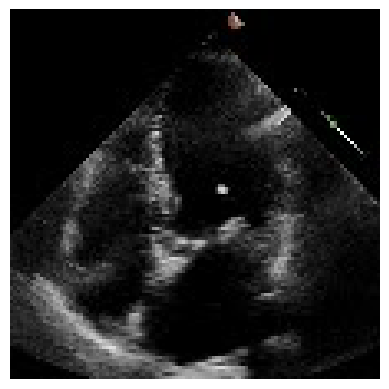

In [13]:
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

In [14]:
ret2, frame2 = cap.read()

In [15]:
print(ret2)


True


In [16]:
print(frame2.shape)

(112, 112, 3)


In [19]:
frame_rgb2=cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB) 

<function matplotlib.pyplot.show(close=None, block=None)>

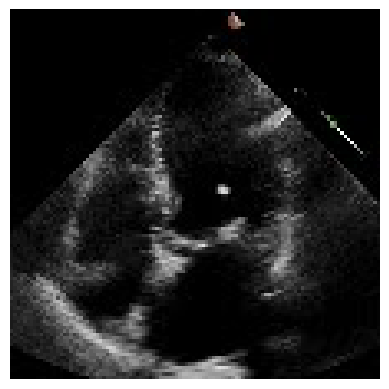

In [20]:
plt.imshow(frame_rgb2)
plt.axis('off')
plt.show

In [21]:
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("Total Frames:", frame_count)
print("FPS:", fps)
print("Width:", width)
print("Height:", height)

Total Frames: 174
FPS: 50.0
Width: 112
Height: 112


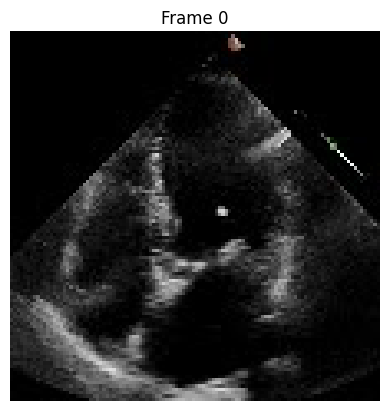

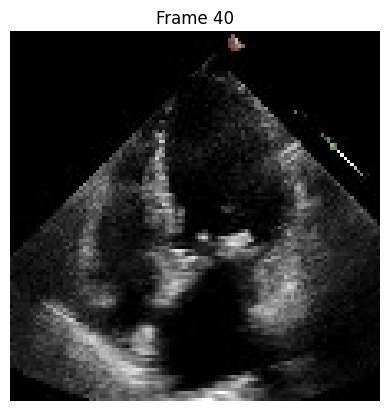

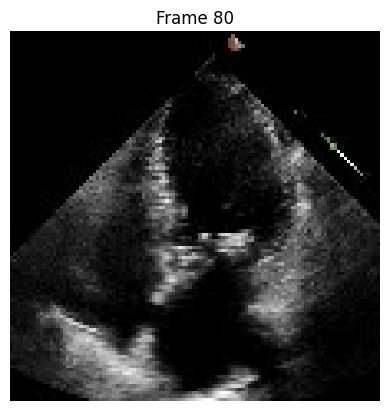

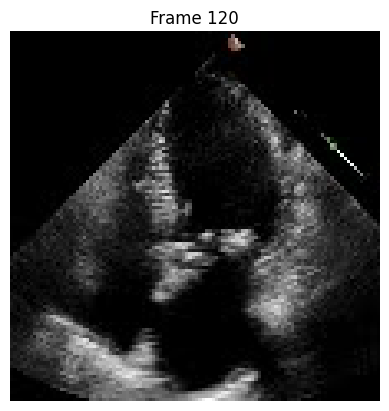

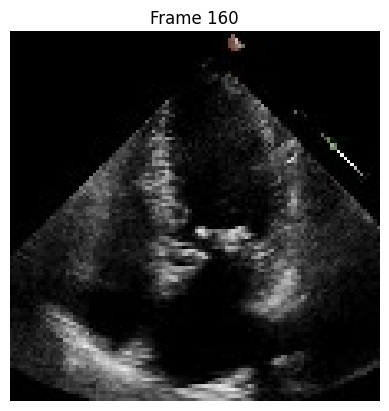

In [22]:
frame_indices = [0, 40, 80, 120, 160]

for idx in frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()

    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.imshow(frame_rgb)
        plt.title(f"Frame {idx}")
        plt.axis("off")
        plt.show()

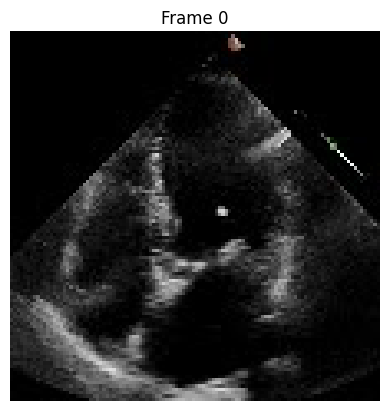

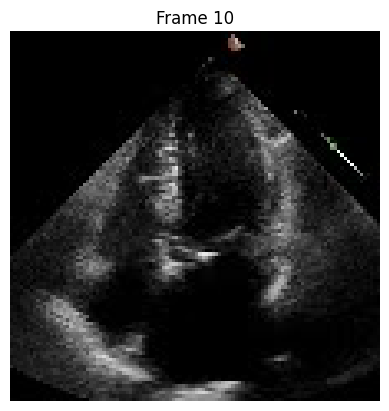

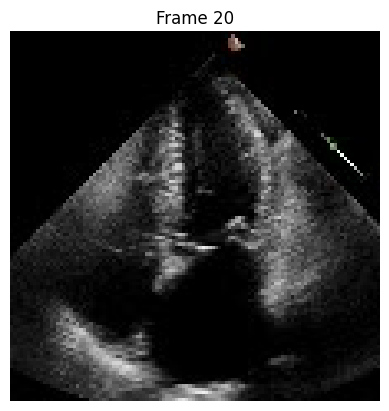

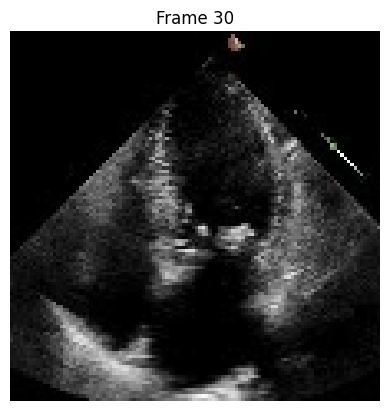

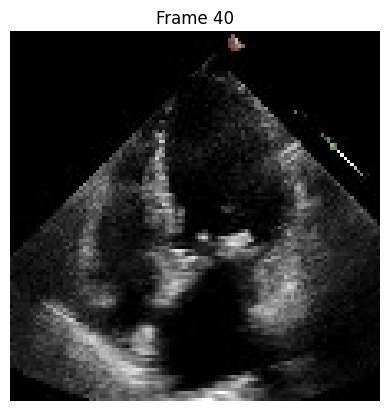

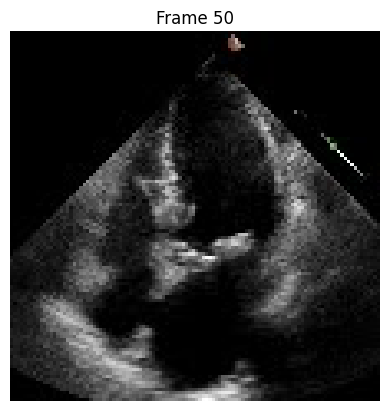

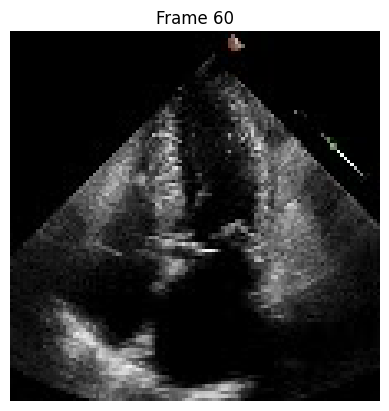

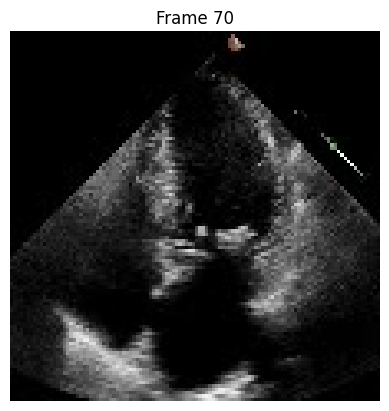

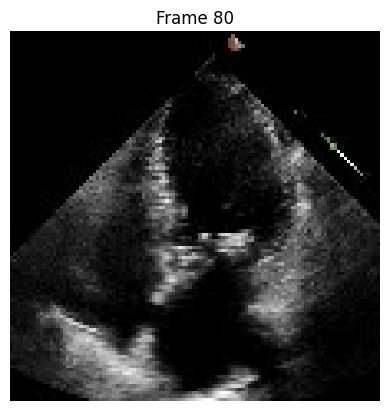

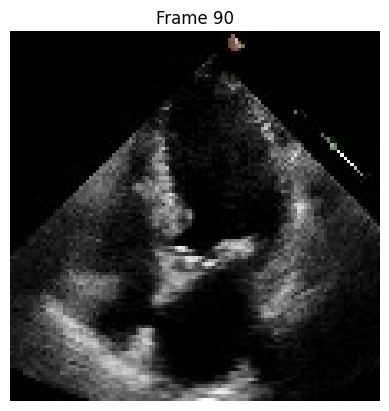

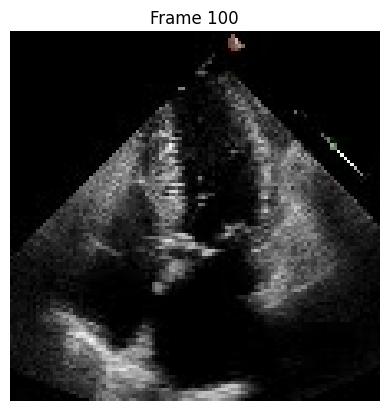

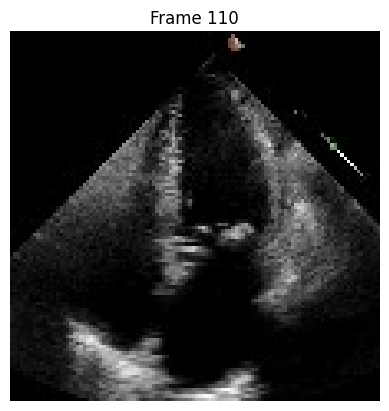

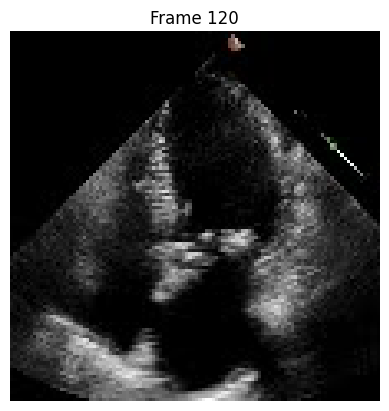

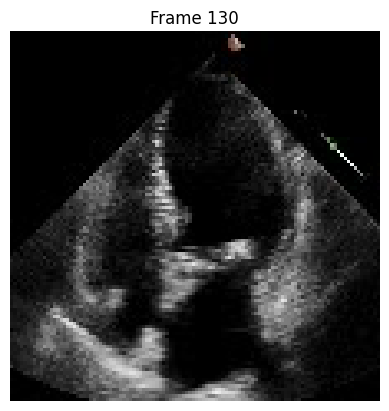

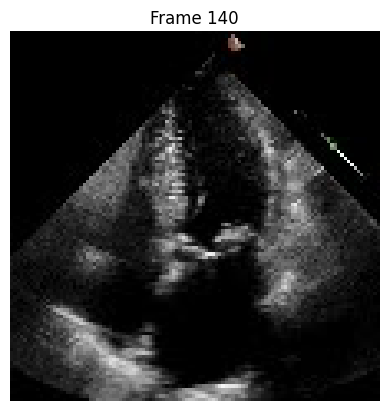

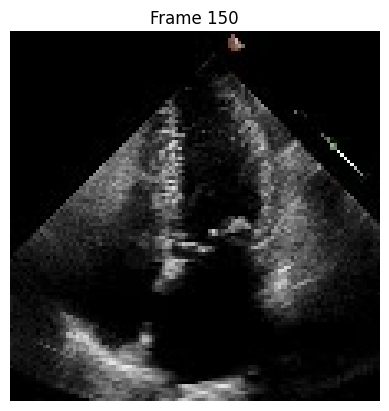

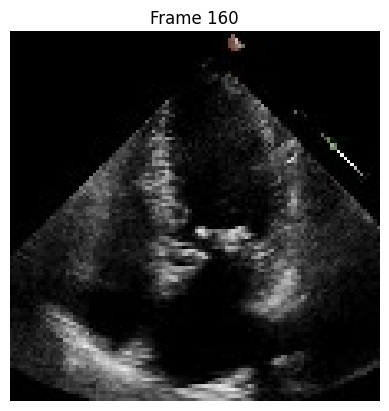

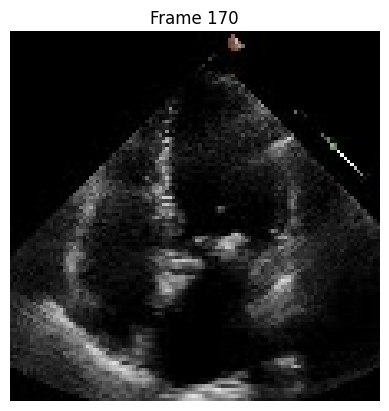

In [38]:
import time

frame_indices = range(0, frame_count, 10)

for idx in frame_indices:
    
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()

    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        plt.imshow(frame_rgb)
        plt.title(f"Frame {idx}")
        plt.axis("off")
        plt.show()

        time.sleep(0.2)

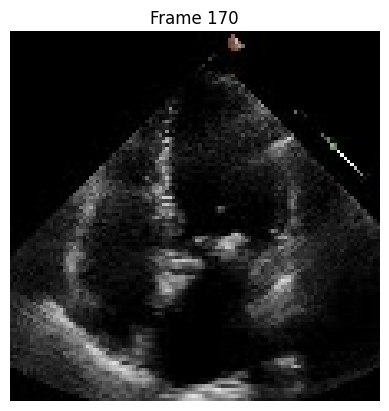

In [34]:
from IPython.display import clear_output
import time

for idx in range(0, frame_count, 10):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()

    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        clear_output(wait=True)
        plt.imshow(frame_rgb)
        plt.title(f"Frame {idx}")
        plt.axis("off")
        plt.show()

        time.sleep(0.2)

In [10]:
import pandas as pd
from pathlib import Path


In [2]:
filelist = pd.read_csv("../../data/raw/EchoNet-Dynamic/FileList.csv")

In [3]:
filelist.head()

,FileName,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames,Split
0,0X100009310A3BD7FC,78.498406,14.881368,69.210534,112,112,50,174,VAL
1,0X1002E8FBACD08477,59.101988,40.383876,98.742884,112,112,50,215,TRAIN
2,0X1005D03EED19C65B,62.363798,14.267784,37.909734,112,112,50,104,TRAIN
3,0X10075961BC11C88E,54.545097,33.143084,72.914210,112,112,55,122,TRAIN
4,0X10094BA0A028EAC3,24.887742,127.581945,169.855024,112,112,52,207,VAL


In [4]:
filelist.columns


Index(['FileName', 'EF', 'ESV', 'EDV', 'FrameHeight', 'FrameWidth', 'FPS',
       'NumberOfFrames', 'Split'],
      dtype='str')

In [5]:
row = filelist.iloc[0]
row

FileName          0X100009310A3BD7FC
EF                         78.498406
ESV                        14.881368
EDV                        69.210534
FrameHeight                      112
FrameWidth                       112
FPS                               50
NumberOfFrames                   174
Split                            VAL
Name: 0, dtype: object

In [11]:
echo_dynamic_dr = Path("../../data/raw/EchoNet-Dynamic")
video_name = row["FileName"]
video_path = echo_dynamic_dr / "Videos"/ video_name
video_path

PosixPath('../../data/raw/EchoNet-Dynamic/Videos/0X100009310A3BD7FC')

In [12]:
tracings = pd.read_csv("../../data/raw/EchoNet-Dynamic/VolumeTracings.csv")

In [14]:
print(tracings.head)

<bound method NDFrame.head of                       FileName         X1         Y1         X2         Y2  \
0       0X100009310A3BD7FC.avi  51.260417  15.348958  64.932292  69.125000   
1       0X100009310A3BD7FC.avi  50.037611  17.167841  53.367222  16.321330   
2       0X100009310A3BD7FC.avi  49.157378  20.407629  57.090549  18.390722   
3       0X100009310A3BD7FC.avi  48.538173  23.581055  59.997339  20.667707   
4       0X100009310A3BD7FC.avi  47.918968  26.754480  62.904129  22.944693   
...                        ...        ...        ...        ...        ...   
425005   0XFEBEEFF93F6FEB9.avi  45.419984  55.131136  69.758942  57.498739   
425006   0XFEBEEFF93F6FEB9.avi  45.017994  57.543075  69.399107  59.914779   
425007   0XFEBEEFF93F6FEB9.avi  44.616005  59.955014  69.039271  62.330818   
425008   0XFEBEEFF93F6FEB9.avi  44.214015  62.366952  68.712853  64.750108   
425009   0XFEBEEFF93F6FEB9.avi  59.371804  66.292488  68.501507  67.180591   

        Frame  
0          46  
1

In [18]:
video_name = "0X100009310A3BD7FC.avi"

video_tracings = tracings[
    tracings["FileName"] == video_name
]

video_tracings

,FileName,X1,Y1,X2,Y2,Frame
0,0X100009310A3BD7FC.avi,51.260417,15.348958,64.932292,69.125000,46
1,0X100009310A3BD7FC.avi,50.037611,17.167841,53.367222,16.321330,46
2,0X100009310A3BD7FC.avi,49.157378,20.407629,57.090549,18.390722,46
3,0X100009310A3BD7FC.avi,48.538173,23.581055,59.997339,20.667707,46
4,0X100009310A3BD7FC.avi,47.918968,26.754480,62.904129,22.944693,46
5,0X100009310A3BD7FC.avi,47.962105,29.759513,65.810920,25.221679,46
6,0X100009310A3BD7FC.avi,48.167915,32.723188,68.247043,27.618326,46
7,0X100009310A3BD7FC.avi,48.373726,35.686864,70.385311,30.090698,46
8,0X100009310A3BD7FC.avi,48.579537,38.650539,72.523579,32.563071,46
9,0X100009310A3BD7FC.avi,49.014039,41.556073,74.151644,35.165156,46


In [17]:
video_tracings["Frame"].unique()

array([46, 61])